In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading datasets
df = pd.read_csv('website_traffic_large_dataset.csv')

In [3]:
#Preview the Data
df.head()

,Date,Traffic_Source,Device_Type,Country,Page_Visited,Sessions,Users,New_Users,Bounce_Rate,Avg_Session_Duration,Conversions,Revenue,Campaign_Name,Month
0,2024-01-01,Google Ads,Tablet,Canada,Landing Page,182,165,83,49.05,110,9,342,Email Campaign,Jan
1,2024-01-01,Facebook Ads,Desktop,UK,Promo Page,179,139,89,29.52,177,14,686,Email Campaign,Jan
2,2024-01-01,Instagram Ads,Tablet,Kenya,Checkout Page,240,194,117,39.66,138,29,1363,None,Jan
3,2024-01-01,Organic Search,Mobile,USA,Product Page,130,107,79,40.60,318,21,546,SEO Campaign,Jan
4,2024-01-01,Direct,Tablet,Australia,Promo Page,168,158,109,36.22,142,4,156,Email Campaign,Jan


In [4]:
#Check Shape (Rows & Columns)
df.shape

(1274, 14)

In [5]:
#View Column Names
df.columns

Index(['Date', 'Traffic_Source', 'Device_Type', 'Country', 'Page_Visited',
       'Sessions', 'Users', 'New_Users', 'Bounce_Rate', 'Avg_Session_Duration',
       'Conversions', 'Revenue', 'Campaign_Name', 'Month'],
      dtype='object')

In [6]:
#Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1274 non-null   object 
 1   Traffic_Source        1274 non-null   object 
 2   Device_Type           1274 non-null   object 
 3   Country               1274 non-null   object 
 4   Page_Visited          1274 non-null   object 
 5   Sessions              1274 non-null   int64  
 6   Users                 1274 non-null   int64  
 7   New_Users             1274 non-null   int64  
 8   Bounce_Rate           1274 non-null   float64
 9   Avg_Session_Duration  1274 non-null   int64  
 10  Conversions           1274 non-null   int64  
 11  Revenue               1274 non-null   int64  
 12  Campaign_Name         1274 non-null   object 
 13  Month                 1274 non-null   object 
dtypes: float64(1), int64(6), object(7)
memory usage: 139.5+ KB


In [7]:
#Quick Statistical Summary
df.describe()

,Sessions,Users,New_Users,Bounce_Rate,Avg_Session_Duration,Conversions,Revenue
count,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000
mean,285.020408,241.362637,143.736264,41.252072,208.227630,18.997645,738.779435
std,123.116992,106.281860,67.733776,7.712173,65.591705,9.374004,442.668849
min,80.000000,61.000000,31.000000,28.010000,90.000000,3.000000,60.000000
25%,174.000000,148.000000,85.000000,34.660000,154.000000,11.000000,390.000000
50%,281.000000,236.000000,137.000000,41.325000,208.500000,19.000000,663.000000
75%,397.000000,332.750000,194.000000,47.777500,266.000000,27.000000,1023.000000
max,499.000000,469.000000,332.000000,54.940000,319.000000,34.000000,2006.000000


In [8]:
#convert date to the right format
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
#Confirm Conversion
df['Date'].dtype

dtype('<M8[ns]')

In [20]:
df.head()

,Date,Traffic_Source,Device_Type,Country,Page_Visited,Sessions,Users,New_Users,Bounce_Rate,Avg_Session_Duration,Conversions,Revenue,Campaign_Name,Month
0,2024-01-01,Google Ads,Tablet,Canada,Landing Page,182,165,83,49.05,110,9,342,Email Campaign,Jan
1,2024-01-01,Facebook Ads,Desktop,UK,Promo Page,179,139,89,29.52,177,14,686,Email Campaign,Jan
2,2024-01-01,Instagram Ads,Tablet,Kenya,Checkout Page,240,194,117,39.66,138,29,1363,No Campaign,Jan
3,2024-01-01,Organic Search,Mobile,USA,Product Page,130,107,79,40.60,318,21,546,SEO Campaign,Jan
4,2024-01-01,Direct,Tablet,Australia,Promo Page,168,158,109,36.22,142,4,156,Email Campaign,Jan


The Date column was converted to datetime format to enable time-based analysis. Additional features such as Month, Day and Weekday were extracted to uncover temporal trends in traffic and revenue.

In [9]:
#Check Missing Values
df.isnull().sum()

Date                    0
Traffic_Source          0
Device_Type             0
Country                 0
Page_Visited            0
Sessions                0
Users                   0
New_Users               0
Bounce_Rate             0
Avg_Session_Duration    0
Conversions             0
Revenue                 0
Campaign_Name           0
Month                   0
dtype: int64

In [10]:
#Check Duplicates
df.duplicated().sum()

0

In [11]:
#Inspect Unique Values
df['Campaign_Name'].unique()

array(['Email Campaign', 'None', 'SEO Campaign', 'Spring Sale',
       'New Product Launch', 'Winter Sale', 'Brand Awareness'],
      dtype=object)

In [12]:
#Replace "None" with real missing values
df['Campaign_Name'] = df['Campaign_Name'].replace('None', np.nan)

In [13]:
#Verify
df.isnull().sum()

Date                      0
Traffic_Source            0
Device_Type               0
Country                   0
Page_Visited              0
Sessions                  0
Users                     0
New_Users                 0
Bounce_Rate               0
Avg_Session_Duration      0
Conversions               0
Revenue                   0
Campaign_Name           173
Month                     0
dtype: int64

In [14]:
#Fill Missing Values
df['Campaign_Name'] = df['Campaign_Name'].fillna('No Campaign')

In [ ]:
#Clean Final Version
#df['Campaign_Name'] = df['Campaign_Name'].replace('None', np.nan)
#df['Campaign_Name'] = df['Campaign_Name'].fillna('No Campaign')

In [16]:
df['Traffic_Source'].unique()


array(['Google Ads', 'Facebook Ads', 'Instagram Ads', 'Organic Search',
       'Direct', 'Email Marketing', 'Referral'], dtype=object)

In [17]:
df['Device_Type'].unique()

array(['Tablet', 'Desktop', 'Mobile'], dtype=object)

In [18]:
#Standardizing text (Traffic Source, Device Type)
df['Traffic_Source'] = df['Traffic_Source'].str.strip().str.title()
df['Device_Type'] = df['Device_Type'].str.strip().str.title()

Text fields such as Traffic Source and Device Type were reviewed for inconsistencies. No major discrepancies were found; however, standardization was applied to ensure uniform formatting.

## Extract Time Features

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

## Feature Engineering

### 1. Conversion Rate
The percentage of visitors who take action (buy, sign up, etc.)

Formula:
Conversion Rate = Conversions / Sessions

In [23]:
df['Conversion_Rate'] = df['Conversions'] / df['Sessions']

In [26]:
#Handle Zero Sessions
df['Conversion_Rate'] = df['Conversions'] / df['Sessions'].replace(0, np.nan)

In [27]:
df[['Sessions', 'Conversions', 'Conversion_Rate']].head()

,Sessions,Conversions,Conversion_Rate
0,182,9,0.049451
1,179,14,0.078212
2,240,29,0.120833
3,130,21,0.161538
4,168,4,0.023810


### 2. Revenue per Session
How much money each visitor generates on average

Formula:
Revenue per Session = Revenue / Sessions

In [25]:
df['Revenue_per_Session'] = df['Revenue'] / df['Sessions']

In [28]:
#Handle Zero Sessions
df['Revenue_per_Session'] = df['Revenue'] / df['Sessions'].replace(0, np.nan)

In [29]:
#Check Result:
df[['Sessions', 'Revenue', 'Revenue_per_Session']].head()

,Sessions,Revenue,Revenue_per_Session
0,182,342,1.879121
1,179,686,3.832402
2,240,1363,5.679167
3,130,546,4.200000
4,168,156,0.928571


## Exploratory Data Analysis (EDA)
- Which traffic source performs best?
- Which campaign drives revenue?
- Device performance
- Monthly trends

### 1. Overview of Key Metrics
- Total traffic
- Total conversions
- Total revenue

In [30]:
df[['Sessions', 'Conversions', 'Revenue']].sum()

Sessions       363116
Conversions     24203
Revenue        941205
dtype: int64

- Total Sessions: 363,116
- Total Conversions: 24,203
- Total Revenue: 941,205
- The website generated a high volume of traffic, but conversions are relatively low compared to sessions, indicating potential inefficiencies in converting visitors into customers.

### 2. Traffic Source Analysis

In [31]:
#Which source brings the most traffic?
df.groupby('Traffic_Source')['Sessions'].sum().sort_values(ascending=False)

Traffic_Source
Email Marketing    54241
Facebook Ads       53976
Google Ads         53555
Instagram Ads      51516
Referral           51342
Organic Search     49400
Direct             49086
Name: Sessions, dtype: int64

- Email Marketing → 54,241 (highest)
- Facebook Ads & Google Ads → close behind

In [32]:
#Which source generates the most revenue?
df.groupby('Traffic_Source')['Revenue'].sum().sort_values(ascending=False)

Traffic_Source
Email Marketing    141302
Instagram Ads      139978
Facebook Ads       136990
Referral           135919
Organic Search     132002
Direct             128327
Google Ads         126687
Name: Revenue, dtype: int64

- Email Marketing → 141,302 (highest)
- Instagram Ads → 139,978
- Facebook Ads → 136,990

In [33]:
#Which source converts best?
df.groupby('Traffic_Source')['Conversion_Rate'].mean().sort_values(ascending=False)

Traffic_Source
Direct             0.091349
Organic Search     0.091239
Instagram Ads      0.088357
Referral           0.085683
Email Marketing    0.082805
Facebook Ads       0.079544
Google Ads         0.075009
Name: Conversion_Rate, dtype: float64

- Direct → 9.13% (highest)
- Organic Search → 9.12%
- Google Ads → 7.50% (lowest)

#### Visualization

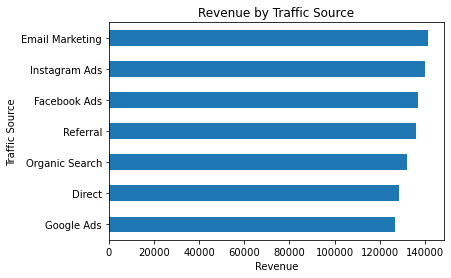

In [34]:
import matplotlib.pyplot as plt

df.groupby('Traffic_Source')['Revenue'].sum().sort_values().plot(kind='barh')
plt.title('Revenue by Traffic Source')
plt.xlabel('Revenue')
plt.ylabel('Traffic Source')
plt.show()

- Email Marketing is the top-performing channel overall, generating the highest traffic and revenue.
- Direct and Organic Search have the highest conversion rates, indicating high-quality, intent-driven users.
- Google Ads drives traffic but has the lowest conversion rate, suggesting inefficient targeting or poor campaign optimization.

#### Business Recommendations:
- Increase investment in Email Marketing
- Strengthen SEO & organic strategies
- Optimize or reduce spend on Google Ads

### 3. Campaign Performance

In [35]:
#Revenue by Campaign
df.groupby('Campaign_Name')['Revenue'].sum().sort_values(ascending=False)

Campaign_Name
Winter Sale           153001
SEO Campaign          137065
Spring Sale           134864
Email Campaign        134153
Brand Awareness       132749
No Campaign           128070
New Product Launch    121303
Name: Revenue, dtype: int64

- Winter Sale → 153,001 (best)
- SEO Campaign → 137,065
- Spring Sale → 134,864

In [36]:
#Conversion Rate by Campaign
df.groupby('Campaign_Name')['Conversion_Rate'].mean().sort_values(ascending=False)

Campaign_Name
New Product Launch    0.091663
Spring Sale           0.087026
SEO Campaign          0.086436
Winter Sale           0.086269
Brand Awareness       0.082082
Email Campaign        0.080578
No Campaign           0.080304
Name: Conversion_Rate, dtype: float64

- New Product Launch → 9.17% (best)
- Spring Sale → 8.70%
- SEO Campaign → 8.64%

#### Visualization

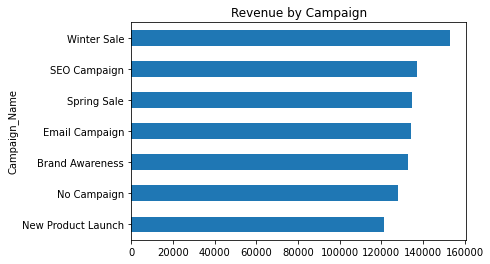

In [37]:
df.groupby('Campaign_Name')['Revenue'].sum().sort_values().plot(kind='barh')
plt.title('Revenue by Campaign')
plt.show()

- The Winter Sale campaign is the highest revenue generator, indicating strong seasonal demand.
- The New Product Launch campaign has the highest conversion rate, meaning it is highly effective at turning visitors into customers.
- No Campaign” still generates significant revenue → strong organic/brand-driven traffic

#### Recommendations:
- Scale Winter Sale–type promotions
- Replicate strategies from New Product Launch
- Invest more in brand visibility (organic growth)

### 4. Device Analysis

In [38]:
#Sessions by Device
df.groupby('Device_Type')['Sessions'].sum()

Device_Type
Desktop    112989
Mobile     134995
Tablet     115132
Name: Sessions, dtype: int64

- Mobile → 134,995 (highest)
- Tablet → 115,132
- Desktop → 112,989

In [39]:
#Conversion Rate by Device
df.groupby('Device_Type')['Conversion_Rate'].mean()

Device_Type
Desktop    0.081990
Mobile     0.084138
Tablet     0.088384
Name: Conversion_Rate, dtype: float64

- Tablet → 8.84% (highest)
- Mobile → 8.41%
- Desktop → 8.19% (lowest)

#### Visualization

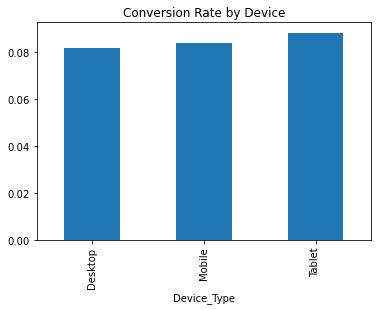

In [40]:
df.groupby('Device_Type')['Conversion_Rate'].mean().plot(kind='bar')
plt.title('Conversion Rate by Device')
plt.show()

- Mobile drives the most traffic but does not have the highest conversion rate.
- Tablet users convert the best, indicating better user experience or more engaged users.

#### Recommendations:
- Optimize mobile UX and checkout flow 🚨
- Investigate why tablet performs best (layout, behavior)

### 5. Time-Based Analysis

In [41]:
#Revenue by Month
df.groupby('Month')['Revenue'].sum().sort_values()

Month
April       144666
June        152345
February    153978
May         157972
January     158412
March       173832
Name: Revenue, dtype: int64

- March → 173,832 (peak)
- January & May also strong

#### Visualization

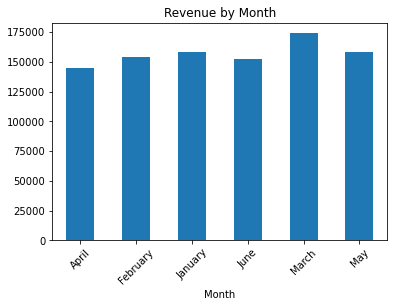

In [42]:
df.groupby('Month')['Revenue'].sum().plot(kind='bar')
plt.title('Revenue by Month')
plt.xticks(rotation=45)
plt.show()

- Revenue peaks in March, indicating seasonal demand or successful campaigns.

In [43]:
#Revenue by Weekday
df.groupby('Weekday')['Revenue'].sum().sort_values()

Weekday
Tuesday      127007
Saturday     127108
Wednesday    130645
Thursday     135688
Monday       136367
Sunday       141338
Friday       143052
Name: Revenue, dtype: int64

- Friday → 143,052 (highest)
- Sunday also strong

- Fridays and weekends generate the most revenue.

#### Recommendations:
- Launch campaigns during high-performing months
- Schedule promotions on Fridays & weekends

### 6. Correlation Analysis

In [44]:
df[['Sessions', 'Conversions', 'Revenue']].corr()

,Sessions,Conversions,Revenue
Sessions,1.000000,-0.000325,0.011924
Conversions,-0.000325,1.000000,0.838844
Revenue,0.011924,0.838844,1.000000


- Sessions vs Revenue → 0.01 (no relationship)
- Conversions vs Revenue → 0.84 (strong relationship)

- More traffic does NOT mean more revenue ❌
- Revenue is strongly driven by conversions, not traffic
- Quality of traffic is more important than quantity.

In [45]:
df.to_csv('cleaned_website_traffic.csv', index=False)
df.to_excel('cleaned_website_traffic.xlsx', index=False)

## EXECUTIVE SUMMARY
The analysis revealed that while the website generates substantial traffic, conversion performance is the primary driver of revenue. Email Marketing emerged as the top-performing channel, while Direct and Organic Search delivered the highest conversion efficiency. Seasonal campaigns such as Winter Sale significantly boosted revenue and user behavior varied across devices, with mobile driving traffic but underperforming in conversions. Overall, the findings highlight the importance of optimizing conversion strategies and focusing on high-quality traffic sources.